# Expolrotary data analysis

## Import libraries

In [124]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
import plotly.express as px

## Load Data

In [125]:
sales_train = pd.read_csv("E:/sales_predict/datasets/sales_train.csv")
items = pd.read_csv("E:/sales_predict/datasets/items.csv")
item_categories = pd.read_csv("E:/sales_predict/datasets/item_categories.csv")
shops = pd.read_csv("E:/sales_predict/datasets/shops.csv")
test = pd.read_csv("E:/sales_predict/datasets/test.csv")
sample_submission = pd.read_csv("E:/sales_predict/datasets/sample_submission.csv")

## Data merging

In [126]:
df = sales_train.merge(items, on='item_id', how='left')
df = df.merge(item_categories, on='item_category_id', how='left')
df = df.merge(shops, on='shop_id', how='left')

## Modeling target variables distributions

### Distribution of monthly item counts by date block number

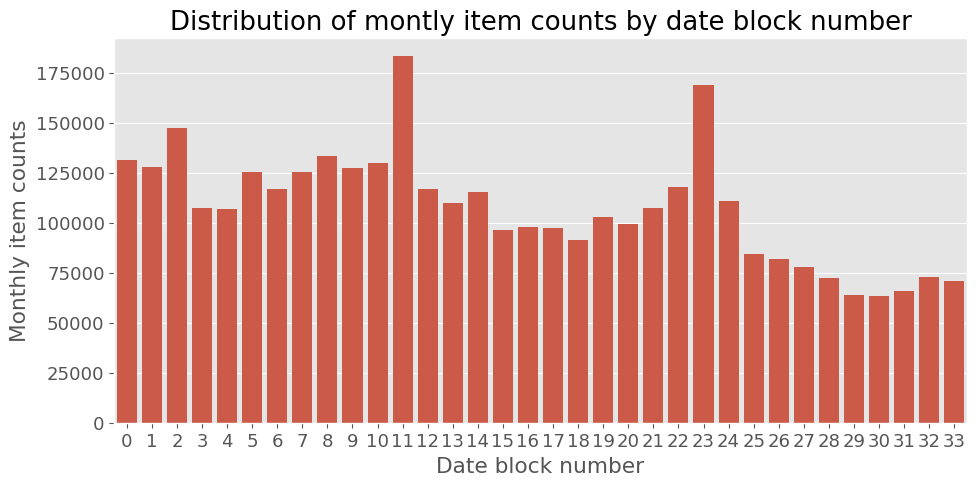

In [127]:
mpl.rc("font", size = 13)
figure, ax = plt.subplots()
figure.set_size_inches(11, 5)

group_month_sum = df.groupby("date_block_num").agg({"item_cnt_day": "sum"}).reset_index()

sns.barplot(x = "date_block_num", y = "item_cnt_day", data = group_month_sum)
ax.set(title = "Distribution of montly item counts by date block number",
       xlabel = "Date block number",
       ylabel = "Monthly item counts");

### Distribution of total item counts by category id 

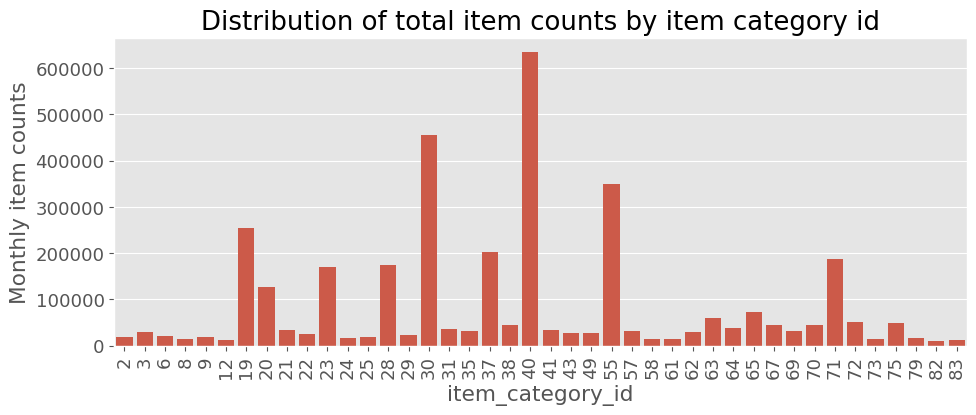

In [128]:
figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

group_cat_sum = df.groupby("item_category_id").agg({"item_cnt_day": "sum"}).reset_index()
group_cat_sum = group_cat_sum[group_cat_sum["item_cnt_day"] > 10000]

sns.barplot(x = "item_category_id", y = "item_cnt_day", data = group_cat_sum)
ax.set(title = "Distribution of total item counts by item category id",
       xlabel = "item_category_id",
       ylabel = "Monthly item counts");
ax.tick_params(axis = "x", labelrotation = 90)

### Checked the most expensive categories

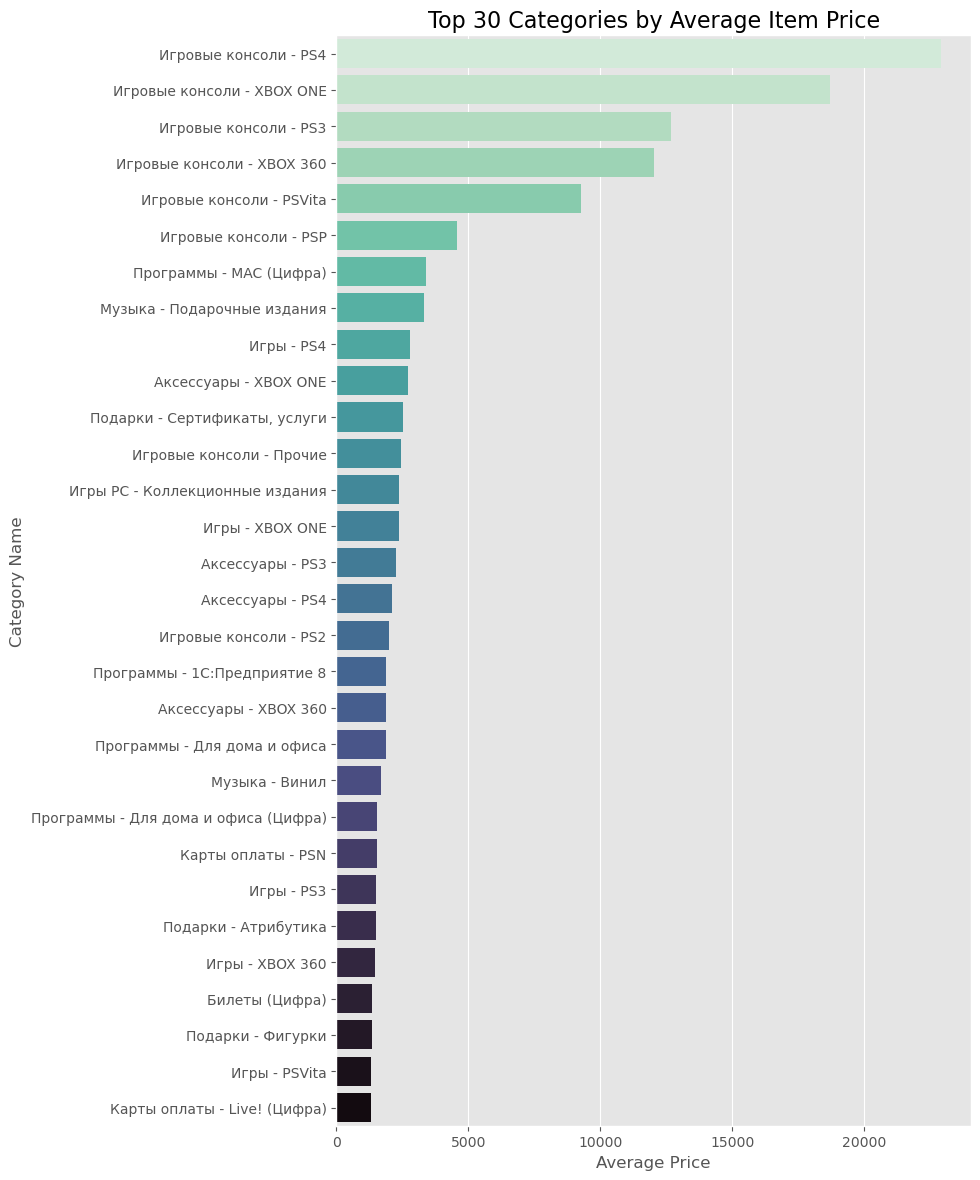

In [129]:
avg_price = df.groupby("item_category_name")["item_price"].mean().sort_values(ascending=False).head(30)
plt.figure(figsize=(10, 12))
sns.barplot(x=avg_price.values, y=avg_price.index, hue=avg_price.index, palette="mako_r", legend=False)
plt.title("Top 30 Categories by Average Item Price", fontsize=16)
plt.xlabel("Average Price", fontsize=12)
plt.ylabel("Category Name", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

We can see that the consoles is the most expensive category, but is it the most valuable to sale?

### Check the best selling products

In [130]:
most_popular = df.groupby("item_id")["item_cnt_day"].sum().sort_values(ascending=False)

C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\3500436897.py:14: UserWarning:

Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.



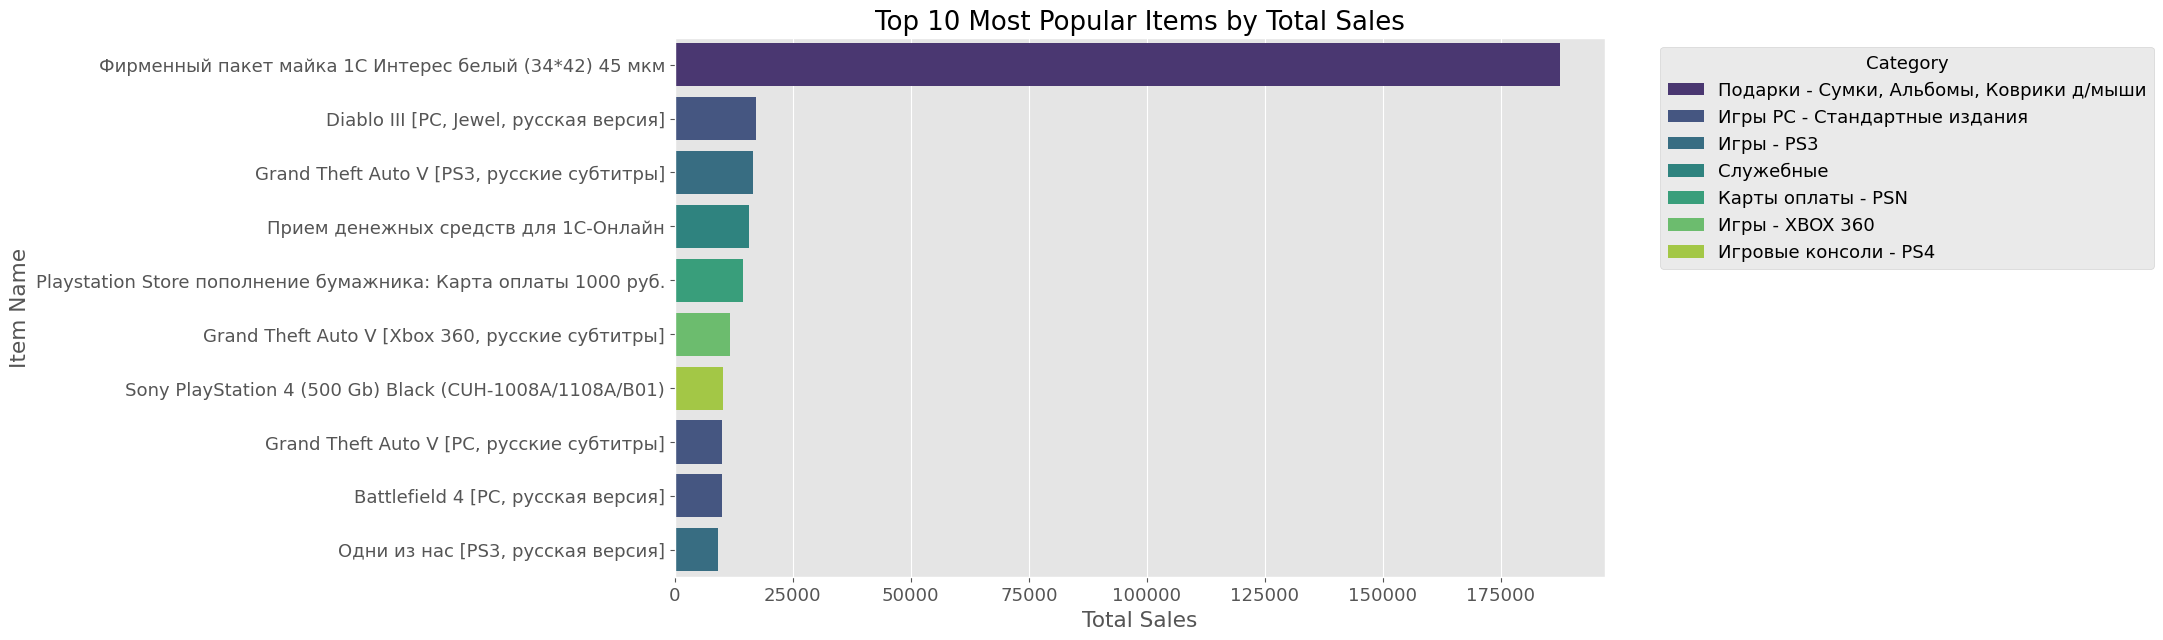

In [131]:
top_10 = most_popular.head(10).reset_index()
top_10 = top_10.merge(items[['item_id', 'item_name', 'item_category_id']], on='item_id', how='left')

top_10 = top_10.merge(item_categories[['item_category_id', 'item_category_name']], on='item_category_id', how='left')

plt.figure(figsize=(12,7))
sns.barplot(x='item_cnt_day', y='item_name', data=top_10,
            palette="viridis", hue='item_category_name')

plt.title("Top 10 Most Popular Items by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item Name")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc='upper left')  # Легенда справа
plt.tight_layout()
plt.show()

Best and worst shops/items

C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\3287022074.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\3287022074.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\3287022074.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\3287022074.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sam

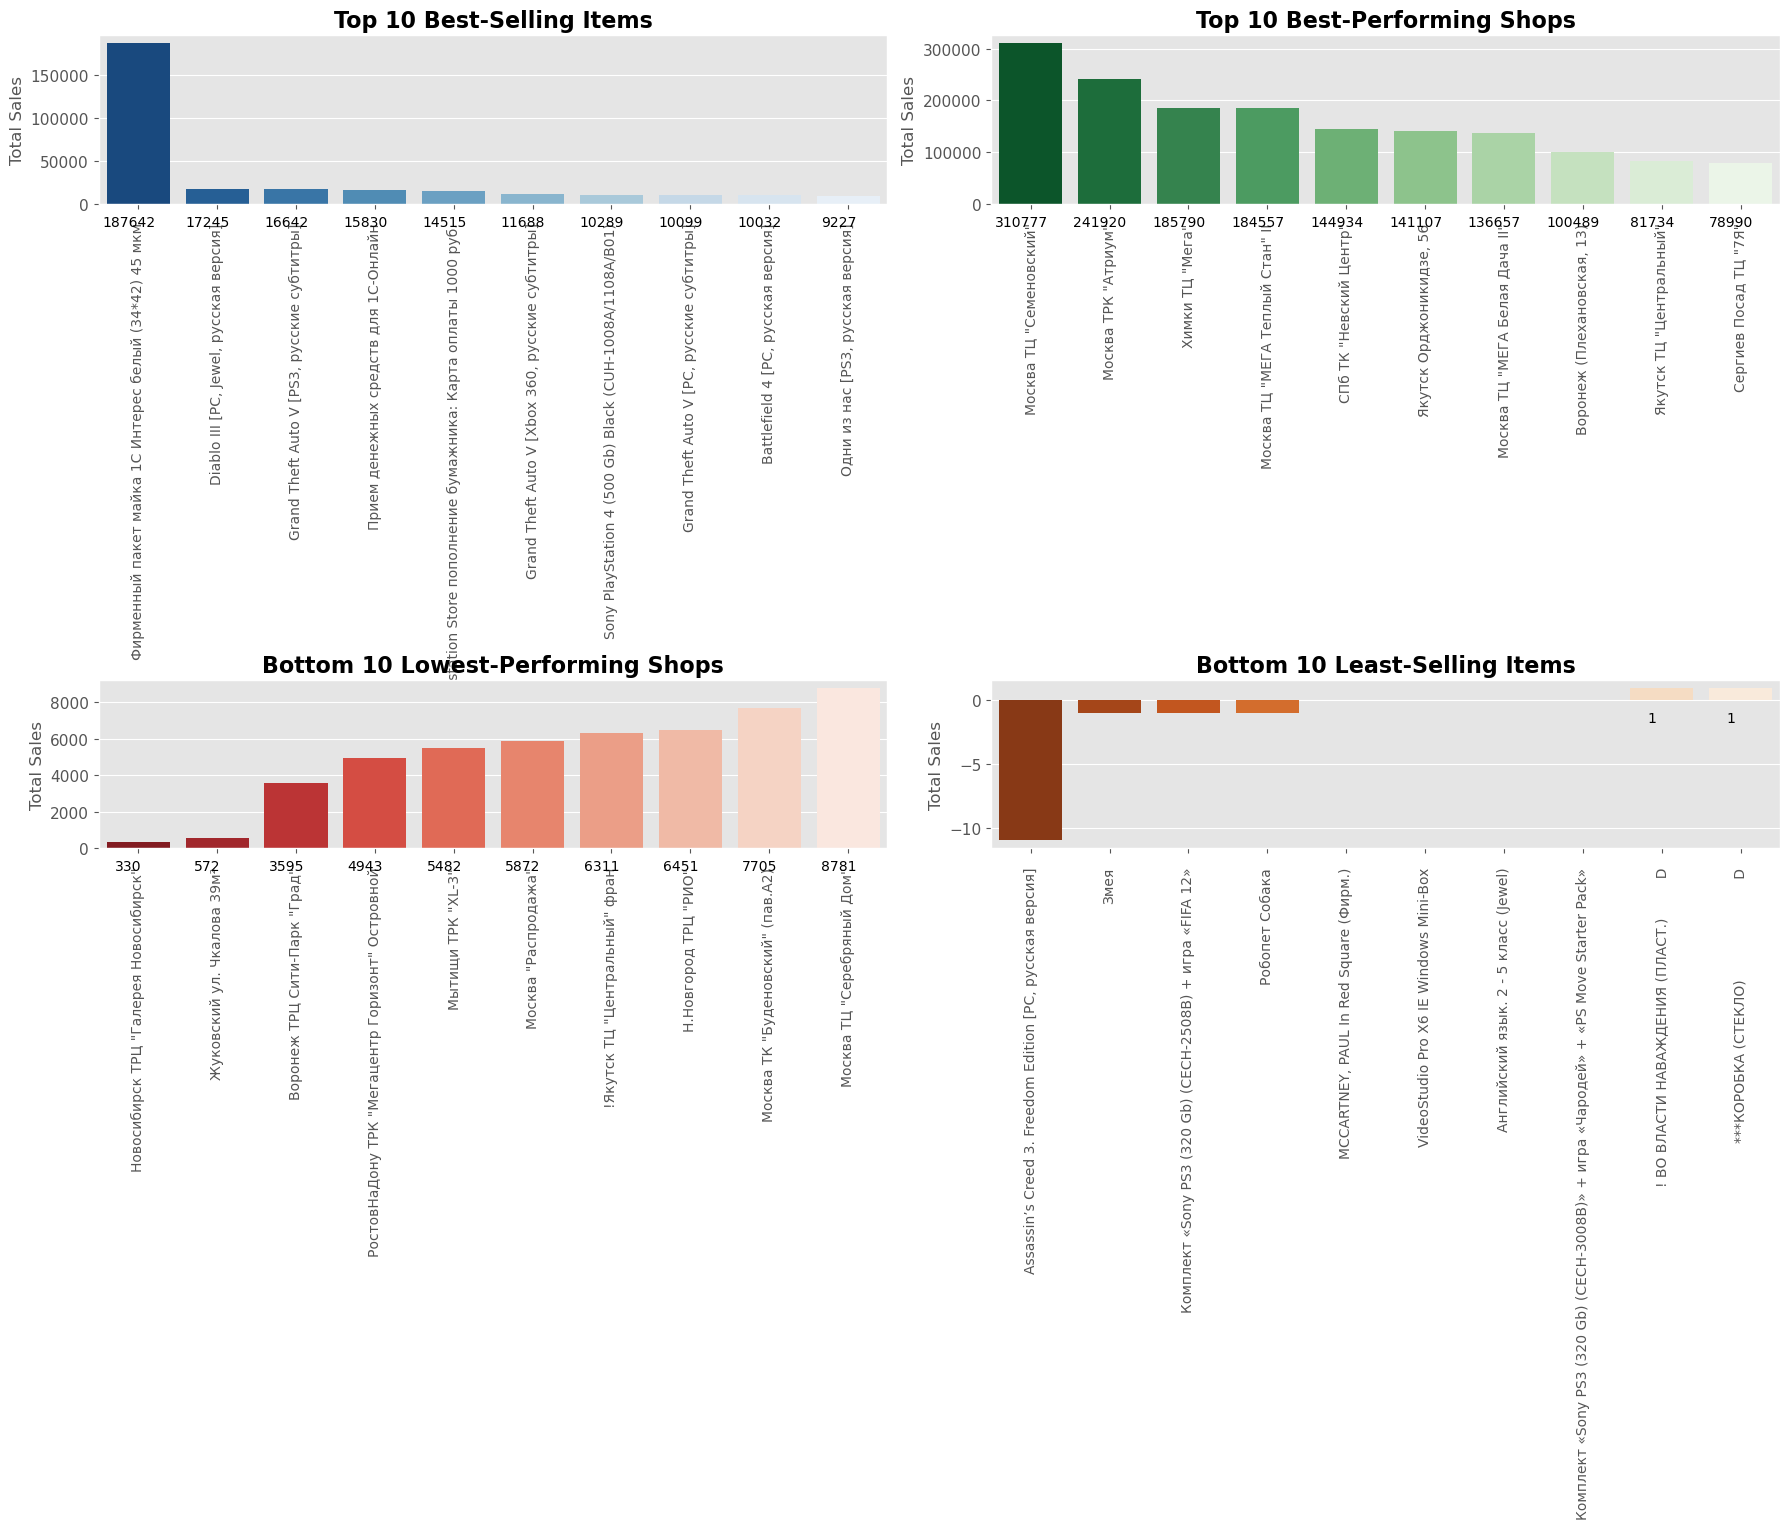

In [132]:
item_sales = df.groupby(['item_id', 'item_name'])['item_cnt_day'].sum().reset_index()
shop_sales = df.groupby(['shop_id', 'shop_name'])['item_cnt_day'].sum().reset_index()

top_items = item_sales.nlargest(10, 'item_cnt_day')
bottom_items = item_sales.nsmallest(10, 'item_cnt_day')
top_shops = shop_sales.nlargest(10, 'item_cnt_day')
bottom_shops = shop_sales.nsmallest(10, 'item_cnt_day')

def annotate_bars_below_left(ax):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x = p.get_x() + p.get_width() * 0.35
            ax.annotate(f'{int(height)}',
                        (x, 0),
                        ha='center', va='top',
                        fontsize=10,
                        color='black',
                        xytext=(0, -8),
                        textcoords='offset points')

plt.style.use('ggplot')

fig, axs = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(ax=axs[0, 0], data=top_items, x='item_name', y='item_cnt_day', palette='Blues_r')
axs[0, 0].set_title('Top 10 Best-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 0])

sns.barplot(ax=axs[0, 1], data=top_shops, x='shop_name', y='item_cnt_day', palette='Greens_r')
axs[0, 1].set_title('Top 10 Best-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[0, 1])

sns.barplot(ax=axs[1, 0], data=bottom_shops, x='shop_name', y='item_cnt_day', palette='Reds_r')
axs[1, 0].set_title('Bottom 10 Lowest-Performing Shops', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 0])

sns.barplot(ax=axs[1, 1], data=bottom_items, x='item_name', y='item_cnt_day', palette='Oranges_r')
axs[1, 1].set_title('Bottom 10 Least-Selling Items', fontsize=16, fontweight='bold')
annotate_bars_below_left(axs[1, 1])

for ax in axs.flatten():
    ax.set_xlabel('')
    ax.set_ylabel('Total Sales', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=10, pad=10)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.subplots_adjust(hspace=2)

for ax in axs[1, :]:
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 - 0.1, pos.width, pos.height])

plt.show()

## Detect trends, seasonality, and cycles

In [133]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['month'] = df['date'].dt.to_period('M')
monthly_sales = df.groupby('month')['item_cnt_day'].sum().to_timestamp()

### Monthly total sales over time

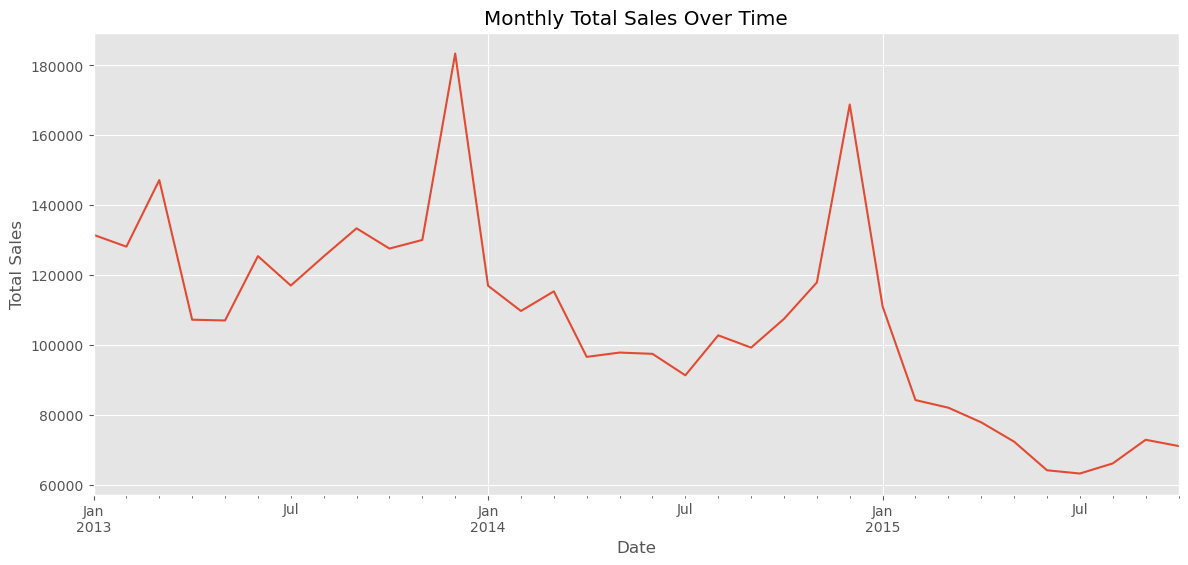

In [134]:
plt.figure(figsize=(14,6))
monthly_sales.plot()
plt.title("Monthly Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

### Seasonal Decomposition of Sales

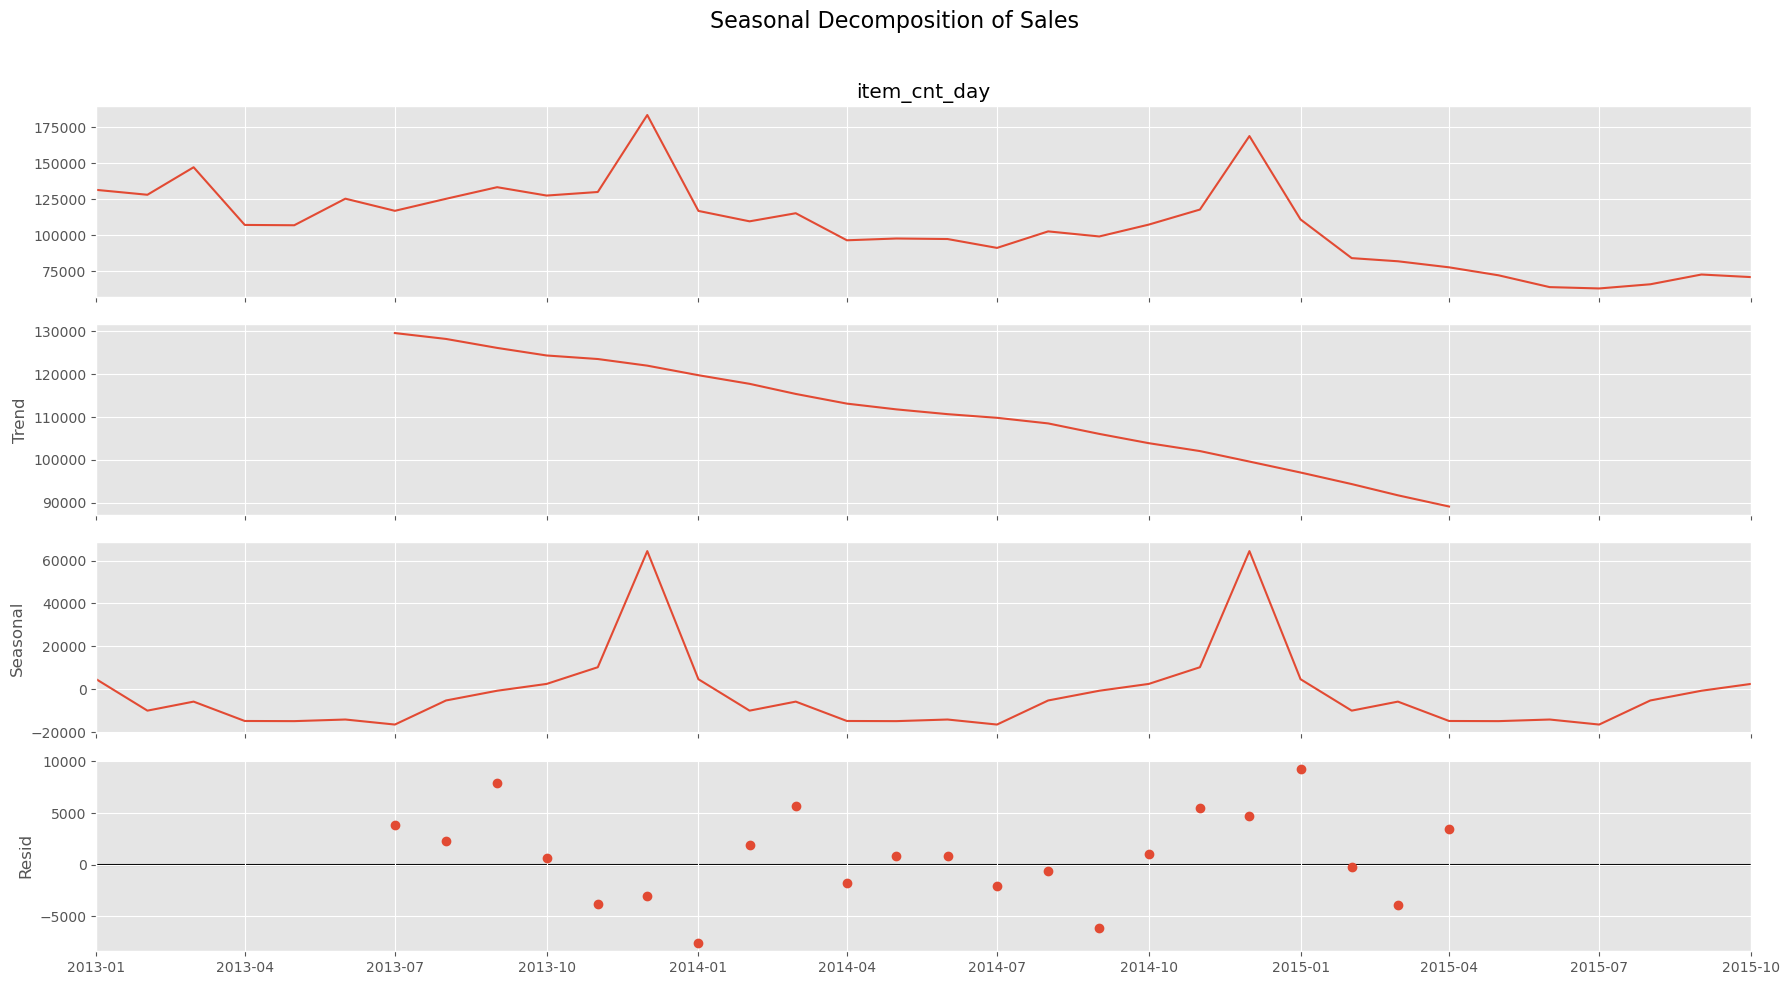

In [135]:
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(18, 10)  
fig.suptitle("Seasonal Decomposition of Sales", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
plt.show()

### Autocorrelation of Monthly Sales

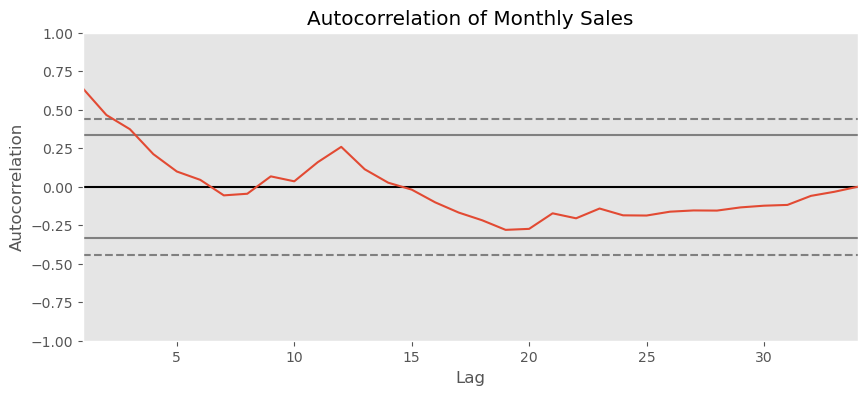

In [136]:
plt.figure(figsize=(10,4))
autocorrelation_plot(monthly_sales)
plt.title("Autocorrelation of Monthly Sales")
plt.show()

### Sales with 3 month Moving Average

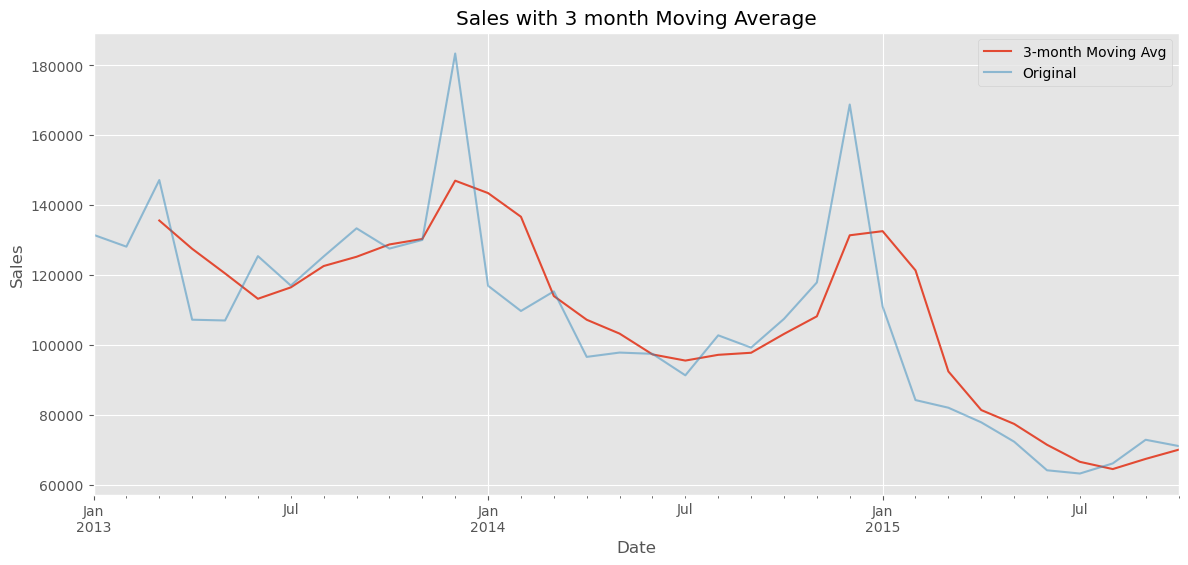

In [137]:
monthly_sales.rolling(window=3).mean().plot(figsize=(14,6), label='3-month Moving Avg')
monthly_sales.plot(alpha=0.5, label='Original')
plt.legend()
plt.title("Sales with 3 month Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

## Shop-level and item-level sales behavior

C:\Users\SUPER\AppData\Local\Temp\ipykernel_16740\2904007000.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




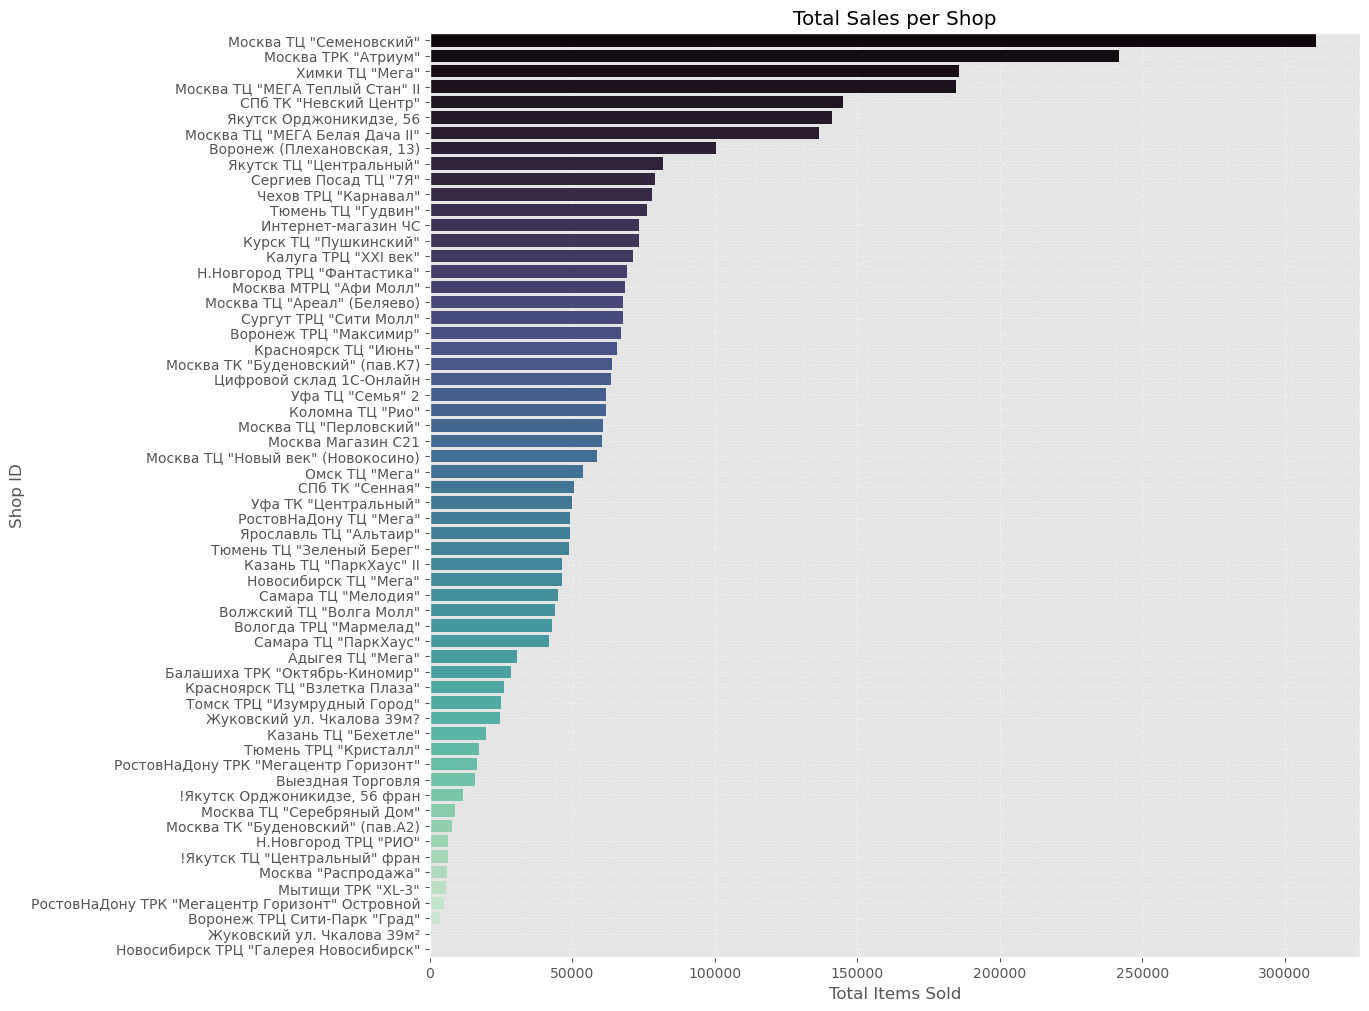

In [138]:
shop_sales = df.groupby('shop_name')['item_cnt_day'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,12))
sns.barplot(x=shop_sales.values, y=shop_sales.index, palette='mako')
plt.title("Total Sales per Shop")
plt.xlabel("Total Items Sold")
plt.ylabel("Shop ID")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# Relationship between price and sales volume

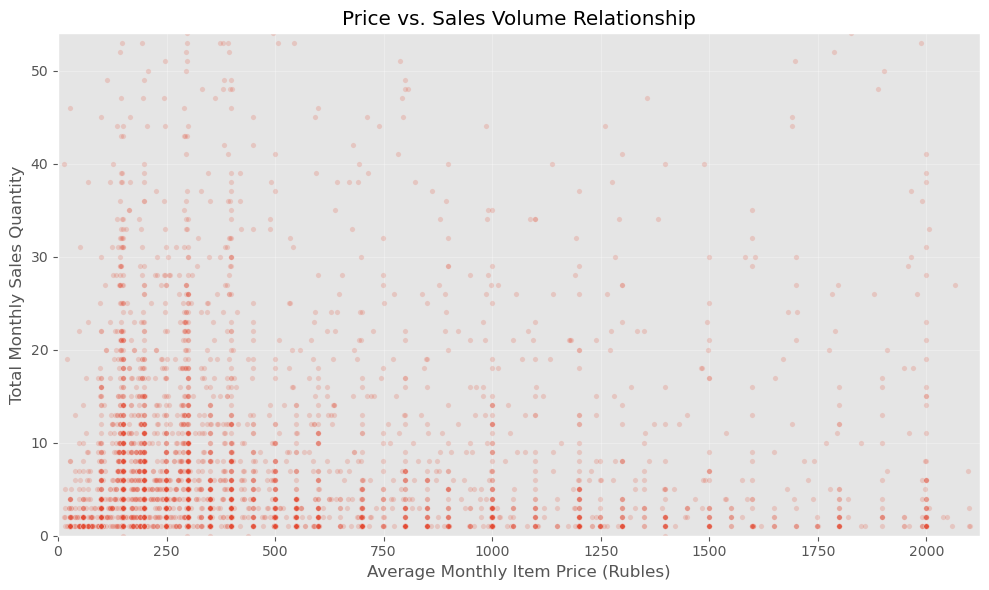

In [147]:
price_sales = df.groupby(['date_block_num', 'item_id']).agg({
    'item_price': 'mean',
    'item_cnt_day': 'sum'
}).reset_index()

plt.figure(figsize=(10, 6))  
sns.scatterplot(
    data=price_sales.sample(5000, random_state=42),  
    x='item_price',
    y='item_cnt_day',
    alpha=0.2,
    s=15  
)

plt.title('Price vs. Sales Volume Relationship')
plt.xlabel('Average Monthly Item Price (Rubles)')
plt.ylabel('Total Monthly Sales Quantity')
plt.grid(alpha=0.3)  

plt.ylim(0, price_sales['item_cnt_day'].quantile(0.95))  
plt.xlim(0, price_sales['item_price'].quantile(0.95))  

plt.tight_layout()
plt.show()

In [146]:
corr_price_sales = price_sales[['item_price', 'item_cnt_day']].corr()
print("Correlation between item_price and item_cnt_day\n", corr_price_sales)

correlation between item_price and item_cnt_day
               item_price  item_cnt_day
item_price             1             0
item_cnt_day           0             1


# Trends depending on shop

In [145]:
pivot_table = pd.pivot_table(
    df,
    values='item_cnt_day',
    index='item_category_id',
    columns='shop_name',
    aggfunc='sum',
    fill_value=0
)

if pivot_table.empty:
    print("Error: Filtered pivot table is empty. Please check the data in df.")
else:
    fig = px.imshow(
        pivot_table,
        labels=dict(x="Shops", y="Product Categories", color="Total Sales"),
        title="Sales Distribution by Product Category and Shop",
        color_continuous_scale='YlGnBu',
        aspect="auto"
    )

    fig.update_xaxes(
        tickangle=45,
        tickfont=dict(size=10),
        title_text="Shop Names"  
    )
    fig.update_yaxes(
        tickfont=dict(size=10),
        title_text="Product Category ID" 
    )
    fig.update_layout(
        width=1200,
        height=800,
        margin=dict(l=100, r=50, t=100, b=100),  # Increased left/bottom margin for category IDs
        coloraxis_colorbar_title_text="Total Sales",  # Clearer colorbar title
        coloraxis_colorbar_title_font_size=12,
        xaxis_title_font_size=12,  # Axis title font size
        yaxis_title_font_size=12
    )

    fig.show()

In [148]:
shop_stats = df.groupby('shop_id')['item_cnt_day'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)
print("Sales statistics by stores (mean and standard deviation):\n", shop_stats)

Sales statistics by stores (mean and standard deviation):
          mean  std
shop_id           
9           4    8
20          3    4
12          2   17
55          2    8
42          1    3
22          1    2
31          1    2
25          1    3
28          1    2
27          1    3
54          1    2
43          1    2
26          1    2
14          1    2
39          1    1
18          1    2
6           1    2
24          1    2
57          1    1
15          1    2
30          1    1
47          1    2
29          1    2
46          1    1
0           1    1
35          1    1
21          1    1
2           1    1
41          1    1
38          1    2
50          1    1
16          1    1
45          1    1
37          1    1
53          1    1
59          1    1
40          1    1
7           1    1
48          1    1
19          1    1
4           1    1
11          1    1
10          1    1
58          1    1
52          1    1
44          1    1
17          1    1
56        

# Seasonality depending on month

In [144]:
df['month'] = pd.to_datetime(df['date']).dt.month

seasonal_cat = df.groupby(['month', 'item_category_id'])['item_cnt_day'].mean().reset_index()

fig = px.imshow(
    seasonal_cat.pivot(index='item_category_id', columns='month', values='item_cnt_day').fillna(0),
    labels=dict(x="Month", y="Item Category ID", color="Average Daily Sales"),
    title="Seasonal Sales Patterns by Product Category",
    color_continuous_scale='YlGnBu',
    aspect="auto"
)

fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
fig.update_yaxes(tickfont=dict(size=10))
fig.update_layout(
    width=1000,
    height=600,
    margin=dict(l=50, r=50, t=100, b=50),
    coloraxis_colorbar_title_font_size=12,
    xaxis_title="Month",
    yaxis_title="Product Category ID",
    coloraxis_colorbar_title_text="Avg Daily Sales"
)

fig.show()

# Conclusion

## Target variables distribution

The chart shows seasonal fluctuations with notable peaks in October 2013 and April 2014, and a decline in 2015.

Popular categories: Categories 19, 30, and 23 likely include high-demand items (e.g. seasonal products like electronics before the holidays or clothing during certain seasons). This is consistent with the peaks identified in the previous graph (e.g. block 9 - October 2013).

Low Demand: Categories with low values ​​may be niche or have limited supply in stores.

Branded T-shirt package 1C best-selling product

Sales are concentrated mainly in the gaming and console categories

Weak link between item_category_id and date_block_num monitors stability of category popularity

Distribution of Total Item Counts by Category: Item distribution is highly skewed. A small number of categories (notably category 0) dominate with extremely high item counts, while the vast majority of the 83 categories have significantly lower counts, many near zero.

Top 30 Categories by Average Item Price: Gaming consoles (PS4, XBOX ONE, PS3, XBOX 360, PSVita, PSP) and digital software/subscriptions (MAC software, Gift Certificates/Services, PSN/Live! cards) command the highest average prices. "Gifts - Certificates/Services" is a notable high-price non-hardware category.

Top 10 Most Popular Items & Categories by Total Sales:

Items: Specific items like the "1C Branded Bag," "Diablo III (PC)," and particularly multiple platform versions of "Grand Theft Auto V" (PS3, X360, PC), "PlayStation Store top-up cards," and "PS4 consoles" are top sellers.

Categories: The categories generating the highest total sales volume are "Gaming Consoles - PS4," "Games - PS3," "Payment Cards - PSN," and "Games - XBOX 360". "PC Games - Standard Editions" and "Gifts - Bags, Albums, Mouse Pads" also show significant sales volume.

## Trends, Seasonality

Data is seasonal and have negative trend

Persistent Decline: Sales have trended downward since mid-2014.

Strong Seasonality: Recurring intra-year patterns drive regular sales cycles.

Long Memory: Autocorrelation indicates sales in any given month influence future months for over 2.5 years (lag 30+).

## Shops and month sales

Moscow stores consistently sell more than others

Month is one of the key factors of sales